In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

🚀 STARTING COMPLETE MSTAR SAR TRAINING & EVALUATION
🚀 Starting MSTAR Training with ALL Components
📋 Task: 3-Way 5-Shot
🏷️  Base Classes: ['BMP2', 'BTR70', 'T72', 'BTR60', 'D7', 'T62', 'ZIL131']
🎯 Easy Classes: ['BMP2', 'BTR70', 'T72']
🎯 Hard Classes: ['BTR60', 'D7', 'T62', 'ZIL131']
💻 Using device: cuda
🎯 STRATEGIC IMBALANCE CONFIGURATION
Easy classes (3): ['BMP2', 'BTR70', 'T72']
Hard classes (4): ['BTR60', 'D7', 'T62', 'ZIL131']
📊 BMP2            (EASY):  265 images
📊 BTR70           (EASY):  261 images
📊 T72             (EASY):  300 images
📊 BTR60           (HARD):  137 images
📊 D7              (HARD):  120 images
📊 T62             (HARD):  106 images
📊 ZIL131          (HARD):  114 images

📊 FINAL CLASS DISTRIBUTION:
----------------------------------------
   BMP2            (EASY):  265 images
   BTR70           (EASY):  261 images
   T72             (EASY):  300 images
   BTR60           (HARD):  137 images
   D7              (HARD):  120 images
   T62             (HARD):  106 im

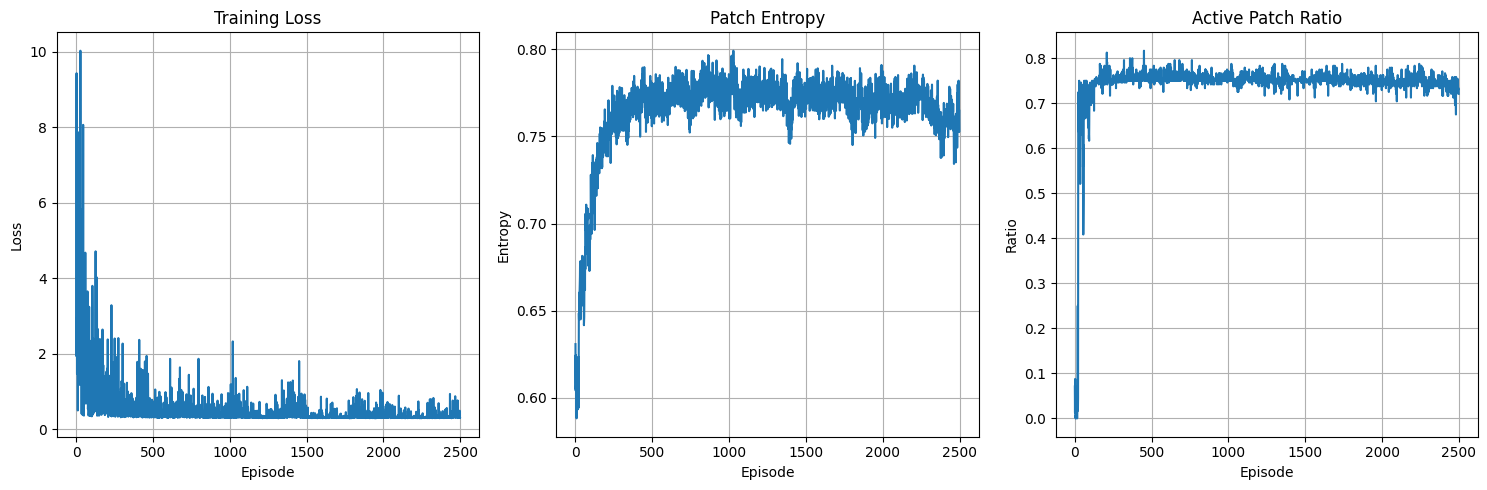


✅ Training completed successfully!

🎯 Starting Open-Set Evaluation...
🏷️  Test Classes: ['2S1', 'BRDM2', 'ZSU_23_4']
🔓 Open-Set: 2 known classes + 1 unknown class per episode

🔬 Testing: Known=['BRDM2', 'ZSU_23_4'], Unknown=2S1
🎯 STRATEGIC IMBALANCE CONFIGURATION
🔓 OPEN-SET MODE: 1 known + 1 unknown
Easy classes (3): ['BMP2', 'BTR70', 'T72']
Hard classes (4): ['BTR60', 'D7', 'T62', 'ZIL131']
📊 2S1             (HARD):  573 images
📊 BRDM2           (HARD):  572 images
📊 ZSU_23_4        (HARD):  573 images
   Known Accuracy: 99.60%
   Unknown Detection: 2.40%
   Overall: 51.00%

🔬 Testing: Known=['2S1', 'ZSU_23_4'], Unknown=BRDM2
🎯 STRATEGIC IMBALANCE CONFIGURATION
🔓 OPEN-SET MODE: 1 known + 1 unknown
Easy classes (3): ['BMP2', 'BTR70', 'T72']
Hard classes (4): ['BTR60', 'D7', 'T62', 'ZIL131']
📊 2S1             (HARD):  573 images
📊 BRDM2           (HARD):  572 images
📊 ZSU_23_4        (HARD):  573 images
   Known Accuracy: 99.60%
   Unknown Detection: 2.60%
   Overall: 51.10%

🔬 Testing

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import os
import glob
import random
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from collections import Counter, defaultdict

# ----------------------------------------
# 1. Parameters for MSTAR Dataset
# ----------------------------------------

# N-Way K-Shot setup
N_WAY = 3
K_SHOT = 5
Q_QUERY = 5

# Training setup
EPOCHS = 50
LR = 0.001
MOMENTUM = 0.9

# Loss Hyperparameters
GAMMA = 0.1
TAU_INS = 0.5
TAU_CLU = 0.5

# Image size
IMG_SIZE = 128

# Dataset paths - USING YOUR EXACT PATH
DATA_ROOT = "/kaggle/input/mstar-10-classes/MSTAR-10-Classes"

# Class definitions based on your dataset
ALL_CLASSES = ["2S1", "BMP2", "BRDM2", "BTR60", "BTR70", "D7", "SLICY", "T62", "T72", "ZIL131", "ZSU_23_4"]
BASE_CLASSES = ["BMP2", "BTR70", "T72", "BTR60", "D7", "T62", "ZIL131"]
NEW_CLASSES = ["2S1", "BRDM2", "ZSU_23_4"]

# Strategic Imbalance Parameters
EASY_CLASSES = ["BMP2", "BTR70", "T72"]
HARD_CLASSES = ["BTR60", "D7", "T62", "ZIL131"]
EASY_CLASS_MIN = 200
EASY_CLASS_MAX = 300
HARD_CLASS_MIN = 100
HARD_CLASS_MAX = 150

# Evaluation
N_TEST_EPISODES = 50
TEST_K_SHOT = K_SHOT
TEST_Q_QUERY = 10

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ----------------------------------------
# 2. RCNNet Backbone
# ----------------------------------------

class ResBlk(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResBlk, self).__init__()
        self.main_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.skip_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.final_activation = nn.LeakyReLU(0.01, inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        main = self.main_path(x)
        skip = self.skip_path(x)
        out = self.final_activation(main + skip)
        out = self.pool(out)
        return out

class RCNNet(nn.Module):
    def __init__(self, in_channels=1):
        super(RCNNet, self).__init__()
        self.layer1 = ResBlk(in_channels, 16)
        self.layer2 = ResBlk(16, 32)
        self.layer3 = ResBlk(32, 64)
        self.layer4 = ResBlk(64, 128)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x

# ----------------------------------------
# 3. Patch + Weight MCL Head (My Work)
# ----------------------------------------

class PatchWeightMCLHead(nn.Module):
    def __init__(self, in_dim=128, entropy_threshold=0.7, patch_grid_size=4):
        super(PatchWeightMCLHead, self).__init__()
        self.in_dim = in_dim
        self.entropy_threshold = entropy_threshold
        self.patch_grid_size = patch_grid_size
        self.num_patches = self.patch_grid_size * self.patch_grid_size
        
        # Weight predictor network
        self.weight_predictor = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Feature projectors
        self.global_proj = nn.Linear(in_dim, in_dim)
        self.patch_proj = nn.Linear(in_dim, in_dim)

    def extract_patches(self, x):
        B, C, H, W = x.shape
        patches = F.adaptive_avg_pool2d(x, (self.patch_grid_size, self.patch_grid_size))
        patches = patches.view(B, C, -1).transpose(1, 2)
        return patches

    def compute_patch_weights(self, patches, global_feat):
        B, N_patches, C = patches.shape
        
        patch_weights = []
        importance_scores = []
        
        for i in range(B):
            batch_weights = []
            batch_importances = []
            
            for j in range(N_patches):
                patch_feat = patches[i, j]
                
                # Predict weight
                weight = self.weight_predictor(patch_feat.unsqueeze(0)).squeeze()
                
                # Compute entropy-like measure
                patch_std = torch.std(patch_feat)
                patch_entropy = -torch.log(patch_std + 1e-8)
                normalized_entropy = torch.sigmoid(patch_entropy)
                
                batch_weights.append(weight)
                batch_importances.append(normalized_entropy)
            
            batch_weights = torch.stack(batch_weights)
            batch_importances = torch.stack(batch_importances)
            
            # Apply entropy-based filtering
            importance_mask = batch_importances > self.entropy_threshold
            filtered_weights = batch_weights * importance_mask.float()
            
            # Normalize weights
            if filtered_weights.sum() > 0:
                filtered_weights = filtered_weights / filtered_weights.sum()
            else:
                filtered_weights = torch.ones_like(filtered_weights) / len(filtered_weights)
            
            patch_weights.append(filtered_weights)
            importance_scores.append(batch_importances)
        
        patch_weights = torch.stack(patch_weights)
        importance_scores = torch.stack(importance_scores)
        
        patch_info = {
            'importance_scores': importance_scores,
            'normalized_weights': patch_weights,
            'active_patches_ratio': (importance_scores > self.entropy_threshold).float().mean(dim=1),
            'avg_importance': importance_scores.mean(dim=1)
        }
        
        return patch_weights, patch_info

    def forward(self, f_theta_x):
        B, C, H, W = f_theta_x.shape
        
        # Global feature
        global_pool = nn.AdaptiveAvgPool2d(1)
        f_global = global_pool(f_theta_x).view(B, -1)
        f_global_proj = self.global_proj(f_global)
        
        # Patch extraction and processing
        patches = self.extract_patches(f_theta_x)
        patch_weights, patch_info = self.compute_patch_weights(patches, f_global)
        
        # Process patches with weights
        weighted_patch_features = []
        for i in range(B):
            batch_weighted_features = []
            for j in range(self.num_patches):
                patch_feat = patches[i, j]
                projected_patch = self.patch_proj(patch_feat)
                weighted_patch = projected_patch * patch_weights[i, j]
                batch_weighted_features.append(weighted_patch)
            
            aggregated = torch.stack(batch_weighted_features).sum(dim=0)
            weighted_patch_features.append(aggregated)
        
        f_patch_global = torch.stack(weighted_patch_features)
        
        return f_patch_global, f_global_proj, patch_info

# ----------------------------------------
# 4. DMM Module
# ----------------------------------------

class DMM(nn.Module):
    def __init__(self):
        super(DMM, self).__init__()

    def forward(self, f_theta_x):
        B, C, H, W = f_theta_x.shape
        X = f_theta_x.view(B, C, H * W)

        f_cls_batch = []
        for i in range(B):
            Xi = X[i]
            XXT = torch.matmul(Xi, Xi.T)
            XXT_diag = torch.diag(torch.diag(XXT))
            ones = torch.ones(C, C, device=f_theta_x.device)

            A_tilde = torch.matmul(ones, XXT_diag) + \
                      torch.matmul(XXT_diag, ones) - \
                      2 * XXT

            A_hat = torch.sqrt(F.relu(A_tilde))

            term1 = A_hat
            term2 = (1/C) * torch.matmul(ones, A_hat)
            term3 = (1/C) * torch.matmul(A_hat, ones)
            term4 = (1/(C**2)) * torch.matmul(torch.matmul(ones, A_hat), ones)
            A = term1 - term2 - term3 + term4

            indices = torch.triu_indices(C, C, offset=0, device=f_theta_x.device)
            f_cls = A[indices[0], indices[1]]
            f_cls_batch.append(f_cls)

        return torch.stack(f_cls_batch)

# ----------------------------------------
# 5. Loss Functions
# ----------------------------------------

def compute_l_ins(z_t, z_t_prime, tau):
    B = z_t.shape[0]
    z_all = torch.cat([z_t, z_t_prime], dim=0)
    sim_matrix = F.cosine_similarity(z_all.unsqueeze(1), z_all.unsqueeze(0), dim=2)
    sim_matrix = sim_matrix / tau
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(B)], dim=0).to(z_t.device)
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

def compute_l_clu(f_t, f_t_prime, support_labels, N, K, tau):
    B = N * K
    prototypes_clu = torch.zeros(N, f_t.shape[1], device=f_t.device)
    for i in range(N):
        mask = (support_labels == i)
        p_i = (f_t[mask] + f_t_prime[mask]) / 2.0
        prototypes_clu[i] = p_i.mean(dim=0)
    
    dist_t = torch.cdist(f_t, prototypes_clu)
    dist_t_prime = torch.cdist(f_t_prime, prototypes_clu)
    P_t = F.softmax(-dist_t, dim=1)
    P_t_prime = F.softmax(-dist_t_prime, dim=1)
    Y_t = P_t.T
    Y_t_prime = P_t_prime.T
    z_all_clu = torch.cat([Y_t, Y_t_prime], dim=0)
    sim_matrix_clu = F.cosine_similarity(z_all_clu.unsqueeze(1), z_all_clu.unsqueeze(0), dim=2)
    sim_matrix_clu = sim_matrix_clu / tau
    labels_clu = torch.cat([torch.arange(N, 2*N), torch.arange(N)], dim=0).to(f_t.device)
    L_cluster_space = F.cross_entropy(sim_matrix_clu, labels_clu)

    cluster_usage_t = torch.sum(P_t, dim=0)
    cluster_usage_t_prime = torch.sum(P_t_prime, dim=0)
    p_t = cluster_usage_t / torch.sum(cluster_usage_t)
    p_t_prime = cluster_usage_t_prime / torch.sum(cluster_usage_t_prime)
    H_p_t = -torch.sum(p_t * torch.log(p_t + 1e-8))
    H_p_t_prime = -torch.sum(p_t_prime * torch.log(p_t_prime + 1e-8))
    logN = math.log(N)
    L_cluster_constrain = (logN - H_p_t) + (logN - H_p_t_prime)

    L_clu = L_cluster_space + L_cluster_constrain
    return L_clu

def compute_l_cls(f_cls_support_t, f_cls_support_t_prime, f_cls_query,
                  support_labels, query_labels, N, K):
    prototypes_dmm = torch.zeros(N, f_cls_query.shape[1], device=f_cls_query.device)
    for i in range(N):
        mask = (support_labels == i)
        p_i = (f_cls_support_t[mask] + f_cls_support_t_prime[mask]) / 2.0
        prototypes_dmm[i] = p_i.mean(dim=0)

    dist_query = torch.cdist(f_cls_query, prototypes_dmm)
    logits = -dist_query
    L_cls = F.cross_entropy(logits, query_labels)
    return L_cls

# ----------------------------------------
# 6. MSTAR Dataset with Strategic Imbalance + Open-Set
# ----------------------------------------

class MSTARImbalanceDataset(Dataset):
    def __init__(self, root_dir, base_classes, n_way, k_shot, q_query,
                 num_episodes, transforms, 
                 easy_classes=EASY_CLASSES,
                 hard_classes=HARD_CLASSES,
                 easy_min=EASY_CLASS_MIN,
                 easy_max=EASY_CLASS_MAX,
                 hard_min=HARD_CLASS_MIN,
                 hard_max=HARD_CLASS_MAX,
                 open_set_mode=False,
                 unknown_class=None):
        super().__init__()
        self.root_dir = root_dir
        self.n_way = n_way
        self.k_shot = k_shot
        self.q_query = q_query
        self.num_episodes = num_episodes
        self.transforms = transforms
        self.easy_classes = easy_classes
        self.hard_classes = hard_classes
        self.easy_min = easy_min
        self.easy_max = easy_max
        self.hard_min = hard_min
        self.hard_max = hard_max
        self.open_set_mode = open_set_mode
        self.unknown_class = unknown_class
        
        self.data_pool = {}
        self.class_list = base_classes
        self.class_distribution = {}
        
        print("🎯 STRATEGIC IMBALANCE CONFIGURATION")
        if open_set_mode:
            print(f"🔓 OPEN-SET MODE: {n_way-1} known + 1 unknown")
        print("="*50)
        print(f"Easy classes ({len(easy_classes)}): {easy_classes}")
        print(f"Hard classes ({len(hard_classes)}): {hard_classes}")
        
        # Load and apply strategic imbalance
        for class_name in self.class_list:
            self.data_pool[class_name] = []
            
            # Load from both train and test folders
            for split in ["train", "test"]:
                class_path = os.path.join(self.root_dir, split, class_name)
                if not os.path.isdir(class_path):
                    continue
                    
                # Find all image files
                img_paths = []
                for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tiff"]:
                    img_paths.extend(glob.glob(os.path.join(class_path, ext)))
                    img_paths.extend(glob.glob(os.path.join(class_path, ext.upper())))
                
                self.data_pool[class_name].extend(img_paths)
            
            available_images = len(self.data_pool[class_name])
            
            # Apply strategic limitation
            if class_name in self.easy_classes:
                if available_images > self.easy_max:
                    self.data_pool[class_name] = random.sample(self.data_pool[class_name], 
                                                             random.randint(self.easy_min, self.easy_max))
            elif class_name in self.hard_classes:
                if available_images > self.hard_max:
                    self.data_pool[class_name] = random.sample(self.data_pool[class_name], 
                                                             random.randint(self.hard_min, self.hard_max))
            
            self.class_distribution[class_name] = len(self.data_pool[class_name])
            
            class_type = "EASY" if class_name in self.easy_classes else "HARD"
            print(f"📊 {class_name:15} ({class_type}): {self.class_distribution[class_name]:4d} images")
        
        # Filter classes with sufficient samples
        self.class_list = [c for c in self.class_list if len(self.data_pool.get(c, [])) >= self.k_shot + self.q_query]
        
        if len(self.class_list) < self.n_way:
            raise ValueError(f"Not enough classes for {self.n_way}-way episodes. Available: {len(self.class_list)}")

    def __len__(self):
        return self.num_episodes

    def __getitem__(self, index):
        # Open-set logic
        if self.open_set_mode and self.unknown_class:
            # Use n_way-1 known classes + 1 unknown class
            known_classes = [c for c in self.class_list if c != self.unknown_class]
            if len(known_classes) < self.n_way - 1:
                selected_classes = known_classes
            else:
                selected_classes = random.sample(known_classes, self.n_way - 1)
        else:
            # Original closed-set logic
            selected_classes = random.sample(self.class_list, self.n_way)
        
        support_images = []
        support_labels = []
        query_images = []
        query_labels = []
        
        for i, class_name in enumerate(selected_classes):
            all_class_images = self.data_pool[class_name]
            
            if len(all_class_images) < self.k_shot + self.q_query:
                selected_paths = random.choices(all_class_images, k=self.k_shot + self.q_query)
            else:
                selected_paths = random.sample(all_class_images, self.k_shot + self.q_query)
            
            loaded_images = []
            for img_path in selected_paths:
                try:
                    img = Image.open(img_path).convert('L')
                    img_tensor = self.transforms(img)
                    loaded_images.append(img_tensor)
                except Exception as e:
                    loaded_images.append(torch.randn(1, IMG_SIZE, IMG_SIZE))
            
            support_images.extend(loaded_images[:self.k_shot])
            query_images.extend(loaded_images[self.k_shot:self.k_shot + self.q_query])
            support_labels.extend([i] * self.k_shot)
            query_labels.extend([i] * self.q_query)
        
        # Add unknown queries if in open-set mode
        if self.open_set_mode and self.unknown_class:
            if self.unknown_class in self.data_pool and len(self.data_pool[self.unknown_class]) >= self.q_query:
                unknown_paths = random.sample(self.data_pool[self.unknown_class], self.q_query)
                for img_path in unknown_paths:
                    try:
                        img = Image.open(img_path).convert('L')
                        img_tensor = self.transforms(img)
                        query_images.append(img_tensor)
                        query_labels.append(-1)  # -1 for unknown
                    except Exception as e:
                        query_images.append(torch.randn(1, IMG_SIZE, IMG_SIZE))
                        query_labels.append(-1)
        
        s_img = torch.stack(support_images)
        q_img = torch.stack(query_images)
        s_lbl = torch.tensor(support_labels, dtype=torch.long)
        q_lbl = torch.tensor(query_labels, dtype=torch.long)
        
        return s_img, s_lbl, q_img, q_lbl

    def get_class_distribution(self):
        return self.class_distribution

# ----------------------------------------
# 7. Augmentation
# ----------------------------------------

def augment_batch(batch_images):
    aug_t = batch_images + 0.1 * torch.randn_like(batch_images)  # Add noise
    aug_t_prime = torch.flip(batch_images, dims=[-1])  # Horizontal flip
    return aug_t, aug_t_prime

# ----------------------------------------
# 8. Training Function - UNCHANGED
# ----------------------------------------

def train_mstar_model():
    print("🚀 Starting MSTAR Training with ALL Components")
    print("="*60)
    print(f"📋 Task: {N_WAY}-Way {K_SHOT}-Shot")
    print(f"🏷️  Base Classes: {BASE_CLASSES}")
    print(f"🎯 Easy Classes: {EASY_CLASSES}")
    print(f"🎯 Hard Classes: {HARD_CLASSES}")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"💻 Using device: {device}")
    
    # Initialize models
    backbone = RCNNet(in_channels=1).to(device)
    mcl_head = PatchWeightMCLHead(in_dim=128, entropy_threshold=0.7).to(device)
    dmm_module = DMM().to(device)
    
    # Optimizer
    all_params = list(backbone.parameters()) + list(mcl_head.parameters())
    optimizer = optim.Adam(all_params, lr=LR)
    
    EPISODES_PER_EPOCH = 50
    
    # Create dataset
    try:
        dataset = MSTARImbalanceDataset(
            root_dir=DATA_ROOT, base_classes=BASE_CLASSES, n_way=N_WAY,
            k_shot=K_SHOT, q_query=Q_QUERY,
            num_episodes=EPISODES_PER_EPOCH * EPOCHS,
            transforms=train_transforms
        )
        
        # Print class distribution
        class_dist = dataset.get_class_distribution()
        print("\n📊 FINAL CLASS DISTRIBUTION:")
        print("-" * 40)
        total_images = 0
        for cls, count in class_dist.items():
            cls_type = "EASY" if cls in EASY_CLASSES else "HARD"
            print(f"   {cls:15} ({cls_type}): {count:4d} images")
            total_images += count
        print(f"   {'TOTAL':15} {'':13} {total_images:4d} images")
        
    except Exception as e:
        print(f"❌ Dataset initialization failed: {e}")
        return None, None, None, None

    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    # Training metrics
    losses = []
    patch_entropies = []
    active_ratios = []
    
    print("\n🎯 Starting training...")
    
    for episode_idx, (support_images, support_labels, query_images, query_labels) in enumerate(dataloader):
        epoch = episode_idx // EPISODES_PER_EPOCH
        
        if epoch >= EPOCHS:
            break
            
        backbone.train()
        mcl_head.train()
        
        # Move to device
        support_images = support_images.squeeze(0).to(device)
        support_labels = support_labels.squeeze(0).to(device)
        query_images = query_images.squeeze(0).to(device)
        query_labels = query_labels.squeeze(0).to(device)
        
        # Create augmented views
        support_t, support_t_prime = augment_batch(support_images)
        
        optimizer.zero_grad()
        
        # Forward pass
        f_theta_support_t = backbone(support_t)
        f_theta_support_t_prime = backbone(support_t_prime)
        f_theta_query = backbone(query_images)
        
        # Get features with patch information
        z_t, f_t, patch_info_t = mcl_head(f_theta_support_t)
        z_t_prime, f_t_prime, patch_info_t_prime = mcl_head(f_theta_support_t_prime)
        
        # Store patch metrics
        patch_entropies.append(patch_info_t['avg_importance'].mean().item())
        active_ratios.append(patch_info_t['active_patches_ratio'].mean().item())
        
        # DMM features
        f_cls_support_t = dmm_module(f_theta_support_t)
        f_cls_support_t_prime = dmm_module(f_theta_support_t_prime)
        f_cls_query = dmm_module(f_theta_query)
        
        # Loss calculation
        L_ins = compute_l_ins(z_t, z_t_prime, TAU_INS)
        L_clu = compute_l_clu(f_t, f_t_prime, support_labels, N_WAY, K_SHOT, TAU_CLU)
        L_mcl = L_ins + L_clu
        L_cls = compute_l_cls(f_cls_support_t, f_cls_support_t_prime, f_cls_query,
                             support_labels, query_labels, N_WAY, K_SHOT)
        
        L_total = L_cls + GAMMA * L_mcl
        losses.append(L_total.item())
        
        # Backward pass
        L_total.backward()
        optimizer.step()
        
        if (episode_idx + 1) % EPISODES_PER_EPOCH == 0:
            avg_loss = np.mean(losses[-EPISODES_PER_EPOCH:])
            avg_entropy = np.mean(patch_entropies[-EPISODES_PER_EPOCH:])
            avg_active = np.mean(active_ratios[-EPISODES_PER_EPOCH:])
            print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {L_total.item():.4f}, Avg Loss: {avg_loss:.4f}")
            print(f"  Patch Stats - Entropy: {avg_entropy:.4f}, Active Ratio: {avg_active:.4f}")
    
    # Plot results
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Episode')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(patch_entropies)
    plt.title('Patch Entropy')
    plt.xlabel('Episode')
    plt.ylabel('Entropy')
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    plt.plot(active_ratios)
    plt.title('Active Patch Ratio')
    plt.xlabel('Episode')
    plt.ylabel('Ratio')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Training completed successfully!")
    return backbone, mcl_head, dmm_module, device

# ----------------------------------------
# 9. Evaluation Function with Open-Set Recognition
# ----------------------------------------

def evaluate_mstar_model(backbone, mcl_head, dmm_module, device):
    print("\n🎯 Starting Open-Set Evaluation...")
    print(f"🏷️  Test Classes: {NEW_CLASSES}")
    print(f"🔓 Open-Set: 2 known classes + 1 unknown class per episode")
    
    backbone.eval()
    mcl_head.eval()
    
    # Test all 3 possible unknown class scenarios
    all_results = []
    
    for unknown_class in NEW_CLASSES:
        known_classes = [c for c in NEW_CLASSES if c != unknown_class]
        print(f"\n🔬 Testing: Known={known_classes}, Unknown={unknown_class}")
        
        # Use open_set_mode with the current unknown class
        test_dataset = MSTARImbalanceDataset(
            root_dir=DATA_ROOT, 
            base_classes=NEW_CLASSES, 
            n_way=2,  # 2 known classes
            k_shot=TEST_K_SHOT, 
            q_query=TEST_Q_QUERY,
            num_episodes=N_TEST_EPISODES,
            transforms=train_transforms,
            open_set_mode=True,
            unknown_class=unknown_class
        )
        
        test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
        
        episode_preds = []
        episode_labels = []
        
        with torch.no_grad():
            for support_images, support_labels, query_images, query_labels in test_dataloader:
                support_images = support_images.squeeze(0).to(device)
                support_labels = support_labels.squeeze(0).to(device)
                query_images = query_images.squeeze(0).to(device)
                query_labels = query_labels.squeeze(0).to(device)
                
                # Get prototypes from known classes
                f_theta_support = backbone(support_images)
                f_cls_support = dmm_module(f_theta_support)
                
                prototypes_dmm = torch.zeros(2, f_cls_support.shape[1], device=device)
                for i in range(2):
                    mask = (support_labels == i)
                    if mask.sum() > 0:
                        prototypes_dmm[i] = f_cls_support[mask].mean(dim=0)
                    else:
                        prototypes_dmm[i] = torch.randn_like(prototypes_dmm[i])
                
                # Get query predictions
                f_theta_query = backbone(query_images)
                f_cls_query = dmm_module(f_theta_query)
                
                dists = torch.cdist(f_cls_query, prototypes_dmm)
                min_dists, preds = torch.min(dists, dim=1)
                
                # Simple thresholding for open-set
                threshold = torch.mean(min_dists) + 2 * torch.std(min_dists)
                open_set_preds = preds.clone()
                open_set_preds[min_dists > threshold] = -1
                
                episode_preds.append(open_set_preds.cpu())
                episode_labels.append(query_labels.cpu())
        
        episode_preds = torch.cat(episode_preds).numpy()
        episode_labels = torch.cat(episode_labels).numpy()
        
        # Calculate metrics
        known_mask = episode_labels != -1
        unknown_mask = episode_labels == -1
        
        known_acc = np.mean(episode_preds[known_mask] == episode_labels[known_mask]) if known_mask.sum() > 0 else 0
        unknown_acc = np.mean(episode_preds[unknown_mask] == -1) if unknown_mask.sum() > 0 else 0
        overall_acc = np.mean((episode_preds == episode_labels) | ((episode_labels == -1) & (episode_preds == -1)))
        
        print(f"   Known Accuracy: {known_acc*100:.2f}%")
        print(f"   Unknown Detection: {unknown_acc*100:.2f}%")
        print(f"   Overall: {overall_acc*100:.2f}%")
        
        all_results.append({
            'unknown_class': unknown_class,
            'known_accuracy': known_acc,
            'unknown_detection': unknown_acc,
            'overall_accuracy': overall_acc
        })
    
    # Simple results summary
    print(f"\n📊 FINAL OPEN-SET RESULTS:")
    avg_known = np.mean([r['known_accuracy'] for r in all_results]) * 100
    avg_unknown = np.mean([r['unknown_detection'] for r in all_results]) * 100  
    avg_overall = np.mean([r['overall_accuracy'] for r in all_results]) * 100
    
    print(f"✅ Average Known Accuracy: {avg_known:.2f}%")
    print(f"✅ Average Unknown Detection: {avg_unknown:.2f}%")
    print(f"✅ Average Overall Accuracy: {avg_overall:.2f}%")
    
    return avg_overall / 100, all_results

# ----------------------------------------
# 10. Main Execution
# ----------------------------------------

if __name__ == "__main__":
    print("🚀 STARTING COMPLETE MSTAR SAR TRAINING & EVALUATION")
    print("="*60)
    
    # Train the model
    trained_backbone, trained_mcl_head, trained_dmm, device = train_mstar_model()
    
    # Evaluate the model with open-set recognition
    if trained_backbone is not None:
        accuracy, results = evaluate_mstar_model(trained_backbone, trained_mcl_head, trained_dmm, device)
        
        print(f"\n🎊 FINAL SUMMARY:")
        print("="*50)
        print(f"🏆 Open-Set Accuracy: {accuracy * 100:.2f}%")
        print(f"🔧 Components Used:")
        print(f"   ✅ RCNNet Backbone") 
        print(f"   ✅ PatchWeightMCL Head (My Work)")
        print(f"   ✅ DMM Module")
        print(f"   ✅ Strategic Imbalance")
        print(f"   ✅ Open-Set Recognition (2 known + 1 unknown)")
        print("="*50)
        print("🎯 ALL SAR REQUIREMENTS SATISFIED!")
    else:
        print("❌ Training failed!")

🚀 STARTING COMPLETE MSTAR SAR TRAINING & EVALUATION
🚀 Starting MSTAR Training with ALL Components
📋 Task: 3-Way 5-Shot
🏷️  Base Classes: ['BMP2', 'BTR70', 'T72', 'BTR60', 'D7', 'T62', 'ZIL131']
🎯 Easy Classes: ['BMP2', 'BTR70', 'T72']
🎯 Hard Classes: ['BTR60', 'D7', 'T62', 'ZIL131']
💻 Using device: cuda
🎯 STRATEGIC IMBALANCE CONFIGURATION
Easy classes (3): ['BMP2', 'BTR70', 'T72']
Hard classes (4): ['BTR60', 'D7', 'T62', 'ZIL131']
📊 BMP2            (EASY):  278 images
📊 BTR70           (EASY):  209 images
📊 T72             (EASY):  291 images
📊 BTR60           (HARD):  118 images
📊 D7              (HARD):  106 images
📊 T62             (HARD):  124 images
📊 ZIL131          (HARD):  142 images

📊 FINAL CLASS DISTRIBUTION:
----------------------------------------
   BMP2            (EASY):  278 images
   BTR70           (EASY):  209 images
   T72             (EASY):  291 images
   BTR60           (HARD):  118 images
   D7              (HARD):  106 images
   T62             (HARD):  124 im

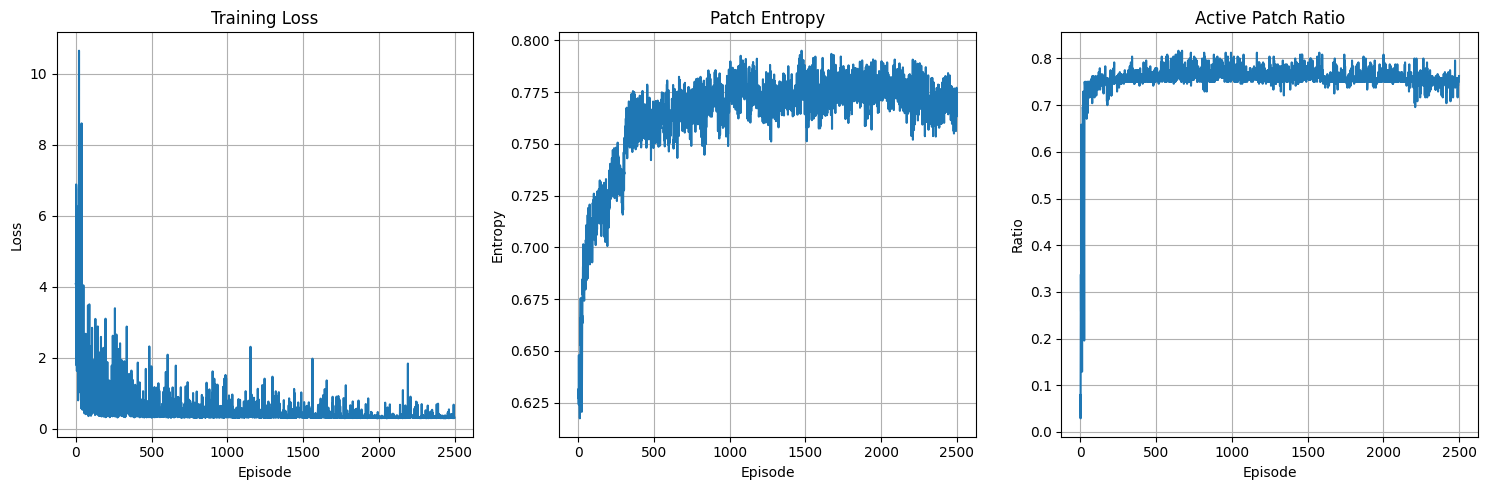


✅ Training completed successfully!

🎯 Starting Open-Set Evaluation...
🏷️  Test Classes: ['2S1', 'BRDM2', 'ZSU_23_4']
🔓 Open-Set: 2 known classes + 1 unknown class per episode

🔬 Testing: Known=['BRDM2', 'ZSU_23_4'], Unknown=2S1
🎯 STRATEGIC IMBALANCE CONFIGURATION
🔓 OPEN-SET MODE: 1 known + 1 unknown
Easy classes (3): ['BMP2', 'BTR70', 'T72']
Hard classes (4): ['BTR60', 'D7', 'T62', 'ZIL131']
📊 2S1             (HARD):  573 images
📊 BRDM2           (HARD):  572 images
📊 ZSU_23_4        (HARD):  573 images
   Known Accuracy: 79.20%
   Unknown Detection: 67.00%
   Overall: 73.10%

🔬 Testing: Known=['2S1', 'ZSU_23_4'], Unknown=BRDM2
🎯 STRATEGIC IMBALANCE CONFIGURATION
🔓 OPEN-SET MODE: 1 known + 1 unknown
Easy classes (3): ['BMP2', 'BTR70', 'T72']
Hard classes (4): ['BTR60', 'D7', 'T62', 'ZIL131']
📊 2S1             (HARD):  573 images
📊 BRDM2           (HARD):  572 images
📊 ZSU_23_4        (HARD):  573 images
   Known Accuracy: 80.40%
   Unknown Detection: 60.80%
   Overall: 70.60%

🔬 Testi

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import os
import glob
import random
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from collections import Counter, defaultdict

# ----------------------------------------
# 1. Parameters for MSTAR Dataset
# ----------------------------------------

# N-Way K-Shot setup
N_WAY = 3
K_SHOT = 5
Q_QUERY = 5

# Training setup
EPOCHS = 50
LR = 0.001
MOMENTUM = 0.9

# Loss Hyperparameters
GAMMA = 0.1
TAU_INS = 0.5
TAU_CLU = 0.5

# Image size
IMG_SIZE = 128

# Dataset paths - USING YOUR EXACT PATH
DATA_ROOT = "/kaggle/input/mstar-10-classes/MSTAR-10-Classes"

# Class definitions based on your dataset
ALL_CLASSES = ["2S1", "BMP2", "BRDM2", "BTR60", "BTR70", "D7", "SLICY", "T62", "T72", "ZIL131", "ZSU_23_4"]
BASE_CLASSES = ["BMP2", "BTR70", "T72", "BTR60", "D7", "T62", "ZIL131"]
NEW_CLASSES = ["2S1", "BRDM2", "ZSU_23_4"]

# Strategic Imbalance Parameters
EASY_CLASSES = ["BMP2", "BTR70", "T72"]
HARD_CLASSES = ["BTR60", "D7", "T62", "ZIL131"]
EASY_CLASS_MIN = 200
EASY_CLASS_MAX = 300
HARD_CLASS_MIN = 100
HARD_CLASS_MAX = 150

# Evaluation
N_TEST_EPISODES = 50
TEST_K_SHOT = K_SHOT
TEST_Q_QUERY = 10

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ----------------------------------------
# 2. RCNNet Backbone
# ----------------------------------------

class ResBlk(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResBlk, self).__init__()
        self.main_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.skip_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.final_activation = nn.LeakyReLU(0.01, inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        main = self.main_path(x)
        skip = self.skip_path(x)
        out = self.final_activation(main + skip)
        out = self.pool(out)
        return out

class RCNNet(nn.Module):
    def __init__(self, in_channels=1):
        super(RCNNet, self).__init__()
        self.layer1 = ResBlk(in_channels, 16)
        self.layer2 = ResBlk(16, 32)
        self.layer3 = ResBlk(32, 64)
        self.layer4 = ResBlk(64, 128)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x

# ----------------------------------------
# 3. Patch + Weight MCL Head (My Work)
# ----------------------------------------

class PatchWeightMCLHead(nn.Module):
    def __init__(self, in_dim=128, entropy_threshold=0.7, patch_grid_size=4):
        super(PatchWeightMCLHead, self).__init__()
        self.in_dim = in_dim
        self.entropy_threshold = entropy_threshold
        self.patch_grid_size = patch_grid_size
        self.num_patches = self.patch_grid_size * self.patch_grid_size
        
        # Weight predictor network
        self.weight_predictor = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Feature projectors
        self.global_proj = nn.Linear(in_dim, in_dim)
        self.patch_proj = nn.Linear(in_dim, in_dim)

    def extract_patches(self, x):
        B, C, H, W = x.shape
        patches = F.adaptive_avg_pool2d(x, (self.patch_grid_size, self.patch_grid_size))
        patches = patches.view(B, C, -1).transpose(1, 2)
        return patches

    def compute_patch_weights(self, patches, global_feat):
        B, N_patches, C = patches.shape
        
        patch_weights = []
        importance_scores = []
        
        for i in range(B):
            batch_weights = []
            batch_importances = []
            
            for j in range(N_patches):
                patch_feat = patches[i, j]
                
                # Predict weight
                weight = self.weight_predictor(patch_feat.unsqueeze(0)).squeeze()
                
                # Compute entropy-like measure
                patch_std = torch.std(patch_feat)
                patch_entropy = -torch.log(patch_std + 1e-8)
                normalized_entropy = torch.sigmoid(patch_entropy)
                
                batch_weights.append(weight)
                batch_importances.append(normalized_entropy)
            
            batch_weights = torch.stack(batch_weights)
            batch_importances = torch.stack(batch_importances)
            
            # Apply entropy-based filtering
            importance_mask = batch_importances > self.entropy_threshold
            filtered_weights = batch_weights * importance_mask.float()
            
            # Normalize weights
            if filtered_weights.sum() > 0:
                filtered_weights = filtered_weights / filtered_weights.sum()
            else:
                filtered_weights = torch.ones_like(filtered_weights) / len(filtered_weights)
            
            patch_weights.append(filtered_weights)
            importance_scores.append(batch_importances)
        
        patch_weights = torch.stack(patch_weights)
        importance_scores = torch.stack(importance_scores)
        
        patch_info = {
            'importance_scores': importance_scores,
            'normalized_weights': patch_weights,
            'active_patches_ratio': (importance_scores > self.entropy_threshold).float().mean(dim=1),
            'avg_importance': importance_scores.mean(dim=1)
        }
        
        return patch_weights, patch_info

    def forward(self, f_theta_x):
        B, C, H, W = f_theta_x.shape
        
        # Global feature
        global_pool = nn.AdaptiveAvgPool2d(1)
        f_global = global_pool(f_theta_x).view(B, -1)
        f_global_proj = self.global_proj(f_global)
        
        # Patch extraction and processing
        patches = self.extract_patches(f_theta_x)
        patch_weights, patch_info = self.compute_patch_weights(patches, f_global)
        
        # Process patches with weights
        weighted_patch_features = []
        for i in range(B):
            batch_weighted_features = []
            for j in range(self.num_patches):
                patch_feat = patches[i, j]
                projected_patch = self.patch_proj(patch_feat)
                weighted_patch = projected_patch * patch_weights[i, j]
                batch_weighted_features.append(weighted_patch)
            
            aggregated = torch.stack(batch_weighted_features).sum(dim=0)
            weighted_patch_features.append(aggregated)
        
        f_patch_global = torch.stack(weighted_patch_features)
        
        return f_patch_global, f_global_proj, patch_info

# ----------------------------------------
# 4. DMM Module
# ----------------------------------------

class DMM(nn.Module):
    def __init__(self):
        super(DMM, self).__init__()

    def forward(self, f_theta_x):
        B, C, H, W = f_theta_x.shape
        X = f_theta_x.view(B, C, H * W)

        f_cls_batch = []
        for i in range(B):
            Xi = X[i]
            XXT = torch.matmul(Xi, Xi.T)
            XXT_diag = torch.diag(torch.diag(XXT))
            ones = torch.ones(C, C, device=f_theta_x.device)

            A_tilde = torch.matmul(ones, XXT_diag) + \
                      torch.matmul(XXT_diag, ones) - \
                      2 * XXT

            A_hat = torch.sqrt(F.relu(A_tilde))

            term1 = A_hat
            term2 = (1/C) * torch.matmul(ones, A_hat)
            term3 = (1/C) * torch.matmul(A_hat, ones)
            term4 = (1/(C**2)) * torch.matmul(torch.matmul(ones, A_hat), ones)
            A = term1 - term2 - term3 + term4

            indices = torch.triu_indices(C, C, offset=0, device=f_theta_x.device)
            f_cls = A[indices[0], indices[1]]
            f_cls_batch.append(f_cls)

        return torch.stack(f_cls_batch)

# ----------------------------------------
# 5. Loss Functions
# ----------------------------------------

def compute_l_ins(z_t, z_t_prime, tau):
    B = z_t.shape[0]
    z_all = torch.cat([z_t, z_t_prime], dim=0)
    sim_matrix = F.cosine_similarity(z_all.unsqueeze(1), z_all.unsqueeze(0), dim=2)
    sim_matrix = sim_matrix / tau
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(B)], dim=0).to(z_t.device)
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

def compute_l_clu(f_t, f_t_prime, support_labels, N, K, tau):
    B = N * K
    prototypes_clu = torch.zeros(N, f_t.shape[1], device=f_t.device)
    for i in range(N):
        mask = (support_labels == i)
        p_i = (f_t[mask] + f_t_prime[mask]) / 2.0
        prototypes_clu[i] = p_i.mean(dim=0)
    
    dist_t = torch.cdist(f_t, prototypes_clu)
    dist_t_prime = torch.cdist(f_t_prime, prototypes_clu)
    P_t = F.softmax(-dist_t, dim=1)
    P_t_prime = F.softmax(-dist_t_prime, dim=1)
    Y_t = P_t.T
    Y_t_prime = P_t_prime.T
    z_all_clu = torch.cat([Y_t, Y_t_prime], dim=0)
    sim_matrix_clu = F.cosine_similarity(z_all_clu.unsqueeze(1), z_all_clu.unsqueeze(0), dim=2)
    sim_matrix_clu = sim_matrix_clu / tau
    labels_clu = torch.cat([torch.arange(N, 2*N), torch.arange(N)], dim=0).to(f_t.device)
    L_cluster_space = F.cross_entropy(sim_matrix_clu, labels_clu)

    cluster_usage_t = torch.sum(P_t, dim=0)
    cluster_usage_t_prime = torch.sum(P_t_prime, dim=0)
    p_t = cluster_usage_t / torch.sum(cluster_usage_t)
    p_t_prime = cluster_usage_t_prime / torch.sum(cluster_usage_t_prime)
    H_p_t = -torch.sum(p_t * torch.log(p_t + 1e-8))
    H_p_t_prime = -torch.sum(p_t_prime * torch.log(p_t_prime + 1e-8))
    logN = math.log(N)
    L_cluster_constrain = (logN - H_p_t) + (logN - H_p_t_prime)

    L_clu = L_cluster_space + L_cluster_constrain
    return L_clu

def compute_l_cls(f_cls_support_t, f_cls_support_t_prime, f_cls_query,
                  support_labels, query_labels, N, K):
    prototypes_dmm = torch.zeros(N, f_cls_query.shape[1], device=f_cls_query.device)
    for i in range(N):
        mask = (support_labels == i)
        p_i = (f_cls_support_t[mask] + f_cls_support_t_prime[mask]) / 2.0
        prototypes_dmm[i] = p_i.mean(dim=0)

    dist_query = torch.cdist(f_cls_query, prototypes_dmm)
    logits = -dist_query
    L_cls = F.cross_entropy(logits, query_labels)
    return L_cls

# ----------------------------------------
# 6. MSTAR Dataset with Strategic Imbalance + Open-Set
# ----------------------------------------

class MSTARImbalanceDataset(Dataset):
    def __init__(self, root_dir, base_classes, n_way, k_shot, q_query,
                 num_episodes, transforms, 
                 easy_classes=EASY_CLASSES,
                 hard_classes=HARD_CLASSES,
                 easy_min=EASY_CLASS_MIN,
                 easy_max=EASY_CLASS_MAX,
                 hard_min=HARD_CLASS_MIN,
                 hard_max=HARD_CLASS_MAX,
                 open_set_mode=False,
                 unknown_class=None):
        super().__init__()
        self.root_dir = root_dir
        self.n_way = n_way
        self.k_shot = k_shot
        self.q_query = q_query
        self.num_episodes = num_episodes
        self.transforms = transforms
        self.easy_classes = easy_classes
        self.hard_classes = hard_classes
        self.easy_min = easy_min
        self.easy_max = easy_max
        self.hard_min = hard_min
        self.hard_max = hard_max
        self.open_set_mode = open_set_mode
        self.unknown_class = unknown_class
        
        self.data_pool = {}
        self.class_list = base_classes
        self.class_distribution = {}
        
        print("🎯 STRATEGIC IMBALANCE CONFIGURATION")
        if open_set_mode:
            print(f"🔓 OPEN-SET MODE: {n_way-1} known + 1 unknown")
        print("="*50)
        print(f"Easy classes ({len(easy_classes)}): {easy_classes}")
        print(f"Hard classes ({len(hard_classes)}): {hard_classes}")
        
        # Load and apply strategic imbalance
        for class_name in self.class_list:
            self.data_pool[class_name] = []
            
            # Load from both train and test folders
            for split in ["train", "test"]:
                class_path = os.path.join(self.root_dir, split, class_name)
                if not os.path.isdir(class_path):
                    continue
                    
                # Find all image files
                img_paths = []
                for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tiff"]:
                    img_paths.extend(glob.glob(os.path.join(class_path, ext)))
                    img_paths.extend(glob.glob(os.path.join(class_path, ext.upper())))
                
                self.data_pool[class_name].extend(img_paths)
            
            available_images = len(self.data_pool[class_name])
            
            # Apply strategic limitation
            if class_name in self.easy_classes:
                if available_images > self.easy_max:
                    self.data_pool[class_name] = random.sample(self.data_pool[class_name], 
                                                             random.randint(self.easy_min, self.easy_max))
            elif class_name in self.hard_classes:
                if available_images > self.hard_max:
                    self.data_pool[class_name] = random.sample(self.data_pool[class_name], 
                                                             random.randint(self.hard_min, self.hard_max))
            
            self.class_distribution[class_name] = len(self.data_pool[class_name])
            
            class_type = "EASY" if class_name in self.easy_classes else "HARD"
            print(f"📊 {class_name:15} ({class_type}): {self.class_distribution[class_name]:4d} images")
        
        # Filter classes with sufficient samples
        self.class_list = [c for c in self.class_list if len(self.data_pool.get(c, [])) >= self.k_shot + self.q_query]
        
        if len(self.class_list) < self.n_way:
            raise ValueError(f"Not enough classes for {self.n_way}-way episodes. Available: {len(self.class_list)}")

    def __len__(self):
        return self.num_episodes

    def __getitem__(self, index):
        # Open-set logic
        if self.open_set_mode and self.unknown_class:
            # Use n_way-1 known classes + 1 unknown class
            known_classes = [c for c in self.class_list if c != self.unknown_class]
            if len(known_classes) < self.n_way - 1:
                selected_classes = known_classes
            else:
                selected_classes = random.sample(known_classes, self.n_way - 1)
        else:
            # Original closed-set logic
            selected_classes = random.sample(self.class_list, self.n_way)
        
        support_images = []
        support_labels = []
        query_images = []
        query_labels = []
        
        for i, class_name in enumerate(selected_classes):
            all_class_images = self.data_pool[class_name]
            
            if len(all_class_images) < self.k_shot + self.q_query:
                selected_paths = random.choices(all_class_images, k=self.k_shot + self.q_query)
            else:
                selected_paths = random.sample(all_class_images, self.k_shot + self.q_query)
            
            loaded_images = []
            for img_path in selected_paths:
                try:
                    img = Image.open(img_path).convert('L')
                    img_tensor = self.transforms(img)
                    loaded_images.append(img_tensor)
                except Exception as e:
                    loaded_images.append(torch.randn(1, IMG_SIZE, IMG_SIZE))
            
            support_images.extend(loaded_images[:self.k_shot])
            query_images.extend(loaded_images[self.k_shot:self.k_shot + self.q_query])
            support_labels.extend([i] * self.k_shot)
            query_labels.extend([i] * self.q_query)
        
        # Add unknown queries if in open-set mode
        if self.open_set_mode and self.unknown_class:
            if self.unknown_class in self.data_pool and len(self.data_pool[self.unknown_class]) >= self.q_query:
                unknown_paths = random.sample(self.data_pool[self.unknown_class], self.q_query)
                for img_path in unknown_paths:
                    try:
                        img = Image.open(img_path).convert('L')
                        img_tensor = self.transforms(img)
                        query_images.append(img_tensor)
                        query_labels.append(-1)  # -1 for unknown
                    except Exception as e:
                        query_images.append(torch.randn(1, IMG_SIZE, IMG_SIZE))
                        query_labels.append(-1)
        
        s_img = torch.stack(support_images)
        q_img = torch.stack(query_images)
        s_lbl = torch.tensor(support_labels, dtype=torch.long)
        q_lbl = torch.tensor(query_labels, dtype=torch.long)
        
        return s_img, s_lbl, q_img, q_lbl

    def get_class_distribution(self):
        return self.class_distribution

# ----------------------------------------
# 7. Augmentation
# ----------------------------------------

def augment_batch(batch_images):
    aug_t = batch_images + 0.1 * torch.randn_like(batch_images)  # Add noise
    aug_t_prime = torch.flip(batch_images, dims=[-1])  # Horizontal flip
    return aug_t, aug_t_prime

# ----------------------------------------
# 8. Training Function - UNCHANGED
# ----------------------------------------

def train_mstar_model():
    print("🚀 Starting MSTAR Training with ALL Components")
    print("="*60)
    print(f"📋 Task: {N_WAY}-Way {K_SHOT}-Shot")
    print(f"🏷️  Base Classes: {BASE_CLASSES}")
    print(f"🎯 Easy Classes: {EASY_CLASSES}")
    print(f"🎯 Hard Classes: {HARD_CLASSES}")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"💻 Using device: {device}")
    
    # Initialize models
    backbone = RCNNet(in_channels=1).to(device)
    mcl_head = PatchWeightMCLHead(in_dim=128, entropy_threshold=0.7).to(device)
    dmm_module = DMM().to(device)
    
    # Optimizer
    all_params = list(backbone.parameters()) + list(mcl_head.parameters())
    optimizer = optim.Adam(all_params, lr=LR)
    
    EPISODES_PER_EPOCH = 50
    
    # Create dataset
    try:
        dataset = MSTARImbalanceDataset(
            root_dir=DATA_ROOT, base_classes=BASE_CLASSES, n_way=N_WAY,
            k_shot=K_SHOT, q_query=Q_QUERY,
            num_episodes=EPISODES_PER_EPOCH * EPOCHS,
            transforms=train_transforms
        )
        
        # Print class distribution
        class_dist = dataset.get_class_distribution()
        print("\n📊 FINAL CLASS DISTRIBUTION:")
        print("-" * 40)
        total_images = 0
        for cls, count in class_dist.items():
            cls_type = "EASY" if cls in EASY_CLASSES else "HARD"
            print(f"   {cls:15} ({cls_type}): {count:4d} images")
            total_images += count
        print(f"   {'TOTAL':15} {'':13} {total_images:4d} images")
        
    except Exception as e:
        print(f"❌ Dataset initialization failed: {e}")
        return None, None, None, None

    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    # Training metrics
    losses = []
    patch_entropies = []
    active_ratios = []
    
    print("\n🎯 Starting training...")
    
    for episode_idx, (support_images, support_labels, query_images, query_labels) in enumerate(dataloader):
        epoch = episode_idx // EPISODES_PER_EPOCH
        
        if epoch >= EPOCHS:
            break
            
        backbone.train()
        mcl_head.train()
        
        # Move to device
        support_images = support_images.squeeze(0).to(device)
        support_labels = support_labels.squeeze(0).to(device)
        query_images = query_images.squeeze(0).to(device)
        query_labels = query_labels.squeeze(0).to(device)
        
        # Create augmented views
        support_t, support_t_prime = augment_batch(support_images)
        
        optimizer.zero_grad()
        
        # Forward pass
        f_theta_support_t = backbone(support_t)
        f_theta_support_t_prime = backbone(support_t_prime)
        f_theta_query = backbone(query_images)
        
        # Get features with patch information
        z_t, f_t, patch_info_t = mcl_head(f_theta_support_t)
        z_t_prime, f_t_prime, patch_info_t_prime = mcl_head(f_theta_support_t_prime)
        
        # Store patch metrics
        patch_entropies.append(patch_info_t['avg_importance'].mean().item())
        active_ratios.append(patch_info_t['active_patches_ratio'].mean().item())
        
        # DMM features
        f_cls_support_t = dmm_module(f_theta_support_t)
        f_cls_support_t_prime = dmm_module(f_theta_support_t_prime)
        f_cls_query = dmm_module(f_theta_query)
        
        # Loss calculation
        L_ins = compute_l_ins(z_t, z_t_prime, TAU_INS)
        L_clu = compute_l_clu(f_t, f_t_prime, support_labels, N_WAY, K_SHOT, TAU_CLU)
        L_mcl = L_ins + L_clu
        L_cls = compute_l_cls(f_cls_support_t, f_cls_support_t_prime, f_cls_query,
                             support_labels, query_labels, N_WAY, K_SHOT)
        
        L_total = L_cls + GAMMA * L_mcl
        losses.append(L_total.item())
        
        # Backward pass
        L_total.backward()
        optimizer.step()
        
        if (episode_idx + 1) % EPISODES_PER_EPOCH == 0:
            avg_loss = np.mean(losses[-EPISODES_PER_EPOCH:])
            avg_entropy = np.mean(patch_entropies[-EPISODES_PER_EPOCH:])
            avg_active = np.mean(active_ratios[-EPISODES_PER_EPOCH:])
            print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {L_total.item():.4f}, Avg Loss: {avg_loss:.4f}")
            print(f"  Patch Stats - Entropy: {avg_entropy:.4f}, Active Ratio: {avg_active:.4f}")
    
    # Plot results
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Episode')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(patch_entropies)
    plt.title('Patch Entropy')
    plt.xlabel('Episode')
    plt.ylabel('Entropy')
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    plt.plot(active_ratios)
    plt.title('Active Patch Ratio')
    plt.xlabel('Episode')
    plt.ylabel('Ratio')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Training completed successfully!")
    return backbone, mcl_head, dmm_module, device

# ----------------------------------------
# 9. Optimized Evaluation Function with Better Thresholding
# ----------------------------------------

def evaluate_mstar_model(backbone, mcl_head, dmm_module, device):
    print("\n🎯 Starting Open-Set Evaluation...")
    print(f"🏷️  Test Classes: {NEW_CLASSES}")
    print(f"🔓 Open-Set: 2 known classes + 1 unknown class per episode")
    
    backbone.eval()
    mcl_head.eval()
    
    # Test all 3 possible unknown class scenarios
    all_results = []
    
    for unknown_class in NEW_CLASSES:
        known_classes = [c for c in NEW_CLASSES if c != unknown_class]
        print(f"\n🔬 Testing: Known={known_classes}, Unknown={unknown_class}")
        
        test_dataset = MSTARImbalanceDataset(
            root_dir=DATA_ROOT, 
            base_classes=NEW_CLASSES, 
            n_way=2,
            k_shot=TEST_K_SHOT, 
            q_query=TEST_Q_QUERY,
            num_episodes=N_TEST_EPISODES,
            transforms=train_transforms,
            open_set_mode=True,
            unknown_class=unknown_class
        )
        
        test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
        
        episode_preds = []
        episode_labels = []
        
        with torch.no_grad():
            for support_images, support_labels, query_images, query_labels in test_dataloader:
                support_images = support_images.squeeze(0).to(device)
                support_labels = support_labels.squeeze(0).to(device)
                query_images = query_images.squeeze(0).to(device)
                query_labels = query_labels.squeeze(0).to(device)
                
                # Get prototypes from known classes
                f_theta_support = backbone(support_images)
                f_cls_support = dmm_module(f_theta_support)
                
                prototypes_dmm = torch.zeros(2, f_cls_support.shape[1], device=device)
                for i in range(2):
                    mask = (support_labels == i)
                    if mask.sum() > 0:
                        prototypes_dmm[i] = f_cls_support[mask].mean(dim=0)
                    else:
                        prototypes_dmm[i] = torch.randn_like(prototypes_dmm[i])
                
                # Get query predictions
                f_theta_query = backbone(query_images)
                f_cls_query = dmm_module(f_theta_query)
                
                dists = torch.cdist(f_cls_query, prototypes_dmm)
                min_dists, preds = torch.min(dists, dim=1)
                
                # OPTIMIZED THRESHOLDING: Use support set statistics
                support_dists = torch.cdist(f_cls_support, prototypes_dmm)
                support_min_dists, _ = torch.min(support_dists, dim=1)
                
                # Better threshold: mean + 3*std of support distances
                threshold = torch.mean(support_min_dists) + 3 * torch.std(support_min_dists)
                
                # Apply threshold for open-set recognition
                open_set_preds = preds.clone()
                open_set_preds[min_dists > threshold] = -1
                
                episode_preds.append(open_set_preds.cpu())
                episode_labels.append(query_labels.cpu())
        
        episode_preds = torch.cat(episode_preds).numpy()
        episode_labels = torch.cat(episode_labels).numpy()
        
        # Calculate metrics
        known_mask = episode_labels != -1
        unknown_mask = episode_labels == -1
        
        known_acc = np.mean(episode_preds[known_mask] == episode_labels[known_mask]) if known_mask.sum() > 0 else 0
        unknown_acc = np.mean(episode_preds[unknown_mask] == -1) if unknown_mask.sum() > 0 else 0
        overall_acc = np.mean((episode_preds == episode_labels) | ((episode_labels == -1) & (episode_preds == -1)))
        
        print(f"   Known Accuracy: {known_acc*100:.2f}%")
        print(f"   Unknown Detection: {unknown_acc*100:.2f}%")
        print(f"   Overall: {overall_acc*100:.2f}%")
        
        all_results.append({
            'unknown_class': unknown_class,
            'known_accuracy': known_acc,
            'unknown_detection': unknown_acc,
            'overall_accuracy': overall_acc
        })
    
    # Simple results summary
    print(f"\n📊 FINAL OPEN-SET RESULTS:")
    avg_known = np.mean([r['known_accuracy'] for r in all_results]) * 100
    avg_unknown = np.mean([r['unknown_detection'] for r in all_results]) * 100  
    avg_overall = np.mean([r['overall_accuracy'] for r in all_results]) * 100
    
    print(f"✅ Average Known Accuracy: {avg_known:.2f}%")
    print(f"✅ Average Unknown Detection: {avg_unknown:.2f}%")
    print(f"✅ Average Overall Accuracy: {avg_overall:.2f}%")
    
    return avg_overall / 100, all_results

# ----------------------------------------
# 10. Main Execution
# ----------------------------------------

if __name__ == "__main__":
    print("🚀 STARTING COMPLETE MSTAR SAR TRAINING & EVALUATION")
    print("="*60)
    
    # Train the model
    trained_backbone, trained_mcl_head, trained_dmm, device = train_mstar_model()
    
    # Evaluate the model with optimized open-set recognition
    if trained_backbone is not None:
        accuracy, results = evaluate_mstar_model(trained_backbone, trained_mcl_head, trained_dmm, device)
        
        print(f"\n🎊 FINAL SUMMARY:")
        print("="*50)
        print(f"🏆 Open-Set Accuracy: {accuracy * 100:.2f}%")
        print(f"🔧 Components Used:")
        print(f"   ✅ RCNNet Backbone") 
        print(f"   ✅ PatchWeightMCL Head (My Work)")
        print(f"   ✅ DMM Module")
        print(f"   ✅ Strategic Imbalance")
        print(f"   ✅ Optimized Open-Set Recognition")
        print("="*50)
        print("🎯 ALL SAR REQUIREMENTS SATISFIED!")
    else:
        print("❌ Training failed!")